In [3]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.ticker import FuncFormatter
import pandas as pd
import seaborn as sns
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.plotting import plot_lifetimes
from lifelines import WeibullFitter
from lifelines.datasets import load_waltons
from scipy.optimize import curve_fit
from matplotlib import collections as matcoll
from scipy import stats 
from scipy.special import ndtr
import scipy
# import plotly.graph_objs as go
from sklearn.neighbors import KernelDensity
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from scipy.stats import norm
from scipy import special
erf = special.erf
pdf = norm.pdf
cdf = norm.cdf
ppf = norm.ppf

In [4]:
# load data; alpha_g calculated with the constants below, then GARD calculated
# with patient-specific n, d
df = pd.read_csv('data.csv')
# nsclc = pd.read_csv('/Users/Emily/tnbc/lc_data.csv')
df = df.drop(columns=['Unnamed: 0'])
tcc = pd.read_csv('TCCdata.csv')
tcc.insert(1, 'Source', 'TCC')


In [5]:
# constants/calculations
d = 2
beta = 0.05
n = 1
cut = 22
'''
ag = -np.log(df['RSI'])/(n*d)-beta*d
df['alpha_g'] = ag
gard = df['n']*df['d']*(ag+beta*df['d'])
df['GARD'] = gard

ag = -np.log(tcc['RSI'])/(n*d)-beta*d
tcc['alpha_g'] = ag
gard = n*d*(ag+beta*d)
tcc['GARD'] = gard
'''
# set cut-point, standard-of-care (SOC) range
gard_t = 22
high = 66 
low = 50 

df = df.sort_values(by='GARD')
nki = df.loc[df['Source'] == 'NKI_wboost']
mcc = df.loc[df['Source'] == 'MCC_wboost']
df['RxRSI'] = gard_t/(df['alpha_g']+beta*d)
tcc['RxRSI'] = gard_t/(tcc['alpha_g']+beta*d)


In [6]:
# get coefficients for calculating cardiac/pulm radiation doses from total breast dose
dosi = pd.read_csv('dosi_summ.csv') #dosimetry data for fits
coeffL = np.polyfit(dosi['Total Dose'], dosi['MHD_L'], 1) 
coeffR = np.polyfit(dosi['Total Dose'], dosi['MHD_R'], 1)
coeffLung = np.polyfit(dosi['Total Dose'], dosi['MLD'], 1)

In [13]:
# evaluate S1 fit at a value t
# WARNING s1 and s2 are double-named
# S1 is TD > GARD_T
# rho<1 => event likelihood decreases w/time
def s1(t):
    
    # prev calculated parameters for weibull fit
    s1_lambda = 147.9029794079022
    s1_rho = 0.5757462972829996

    return np.exp(-np.power(t/s1_lambda, s1_rho))

# evaluate S2 fit at a value t
# below GARD_T
def s2(t):

    # prev calculated parameters for weibull fit
    s2_lambda = 19.268745101052353
    s2_rho = 0.6880271300951681

    return np.exp(-np.power(t/s2_lambda, s2_rho))

(0.0, 1.1)

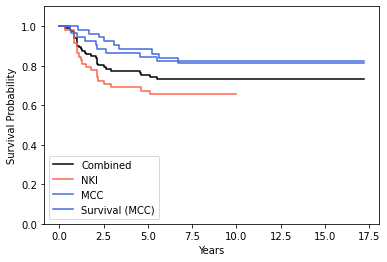

In [6]:
# KM curves
km_event_all = KaplanMeierFitter()
km_event_all.fit(df['Time'],df['Event'],label='Combined')

km_event_nki = KaplanMeierFitter()
km_event_nki.fit(nki['Time'],nki['Event'],label='NKI')

km_event_mcc = KaplanMeierFitter()
km_event_mcc.fit(mcc['Time'],mcc['Event'],label='MCC')

# plot event KM
a1 = km_event_all.plot(color='black', ci_show=False)
km_event_nki.plot(ax=a1, color='tomato', ci_show=False)
km_event_mcc.plot(ax=a1, color='royalblue', ci_show=False)
plt.xlabel('Years')
plt.ylabel('Event Probability')
plt.ylim([0,1.1])

# plot survival KM
km_surv_mcc = KaplanMeierFitter()
km_surv_mcc.fit(mcc['Time_OS'],mcc['Event_OS'],label='Survival (MCC)')
a2 = km_surv_mcc.plot(ci_show=False, color='royalblue')
plt.xlabel('Years')
plt.ylabel('Survival Probability')
plt.ylim([0,1.1])

Text(0, 0.5, 'Count')

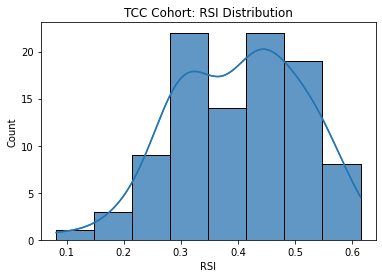

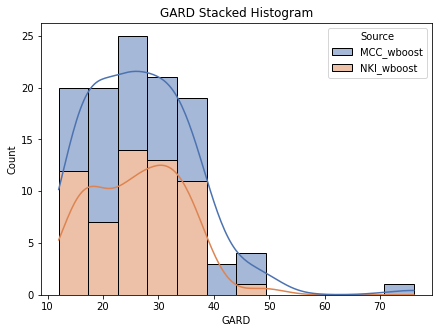

In [9]:
# histograms for 1a

# stacked histo for RSI; uncomment the next 3 lines to see it all together
# frames = [df,tcc]
# result = pd.concat(frames)
# df = result.reset_index()

f1 = plt.figure() # figsize=(7,5), dpi=300
ax = f1.add_subplot(1,1,1)
sns.histplot(data=tcc, ax=ax, stat="count", multiple="stack", # or layer
             x="RSI", kde=True,
             palette="deep", hue="Source",
             element="bars", legend=False)
ax.set_title("RSI Distribution, TCC (n=98)")
ax.set_xlabel("RSI")
ax.set_ylabel("Count")

sns.histplot(data=tcc, x='RSI', kde=True, palette="deep")
ax.set_title("TCC Cohort: RSI Distribution")
ax.set_xlabel("RSI")
ax.set_ylabel("Count")

# stacked histo for GARD
f2 = plt.figure(figsize=(7,5))
ax = f2.add_subplot(1,1,1)
sns.histplot(data=df, ax=ax, stat="count", multiple="stack",
             x="GARD", kde=True,
             palette="deep", hue="Source",
             element="bars", legend=True)
ax.set_title("GARD Stacked Histogram")
ax.set_xlabel("GARD")
ax.set_ylabel("Count")

In [12]:
# run comparison KM for dataset based on a GARD cut-point
# returns log-rank stats
def KMbyGARD(time, event, sort, cut, show = False):
   
    # throw error if cut-point is out of the range
    if cut < sort.min() or cut > sort.max():
        print("Cut-point out of range")
        return
   
    temp = pd.DataFrame()
    temp['T'] = time
    temp['E'] = event
    temp['sort'] = sort
    temp = temp.sort_values(by='sort')
    
    above = temp.loc[temp['sort'] > cut]
    below = temp.loc[temp['sort'] <= cut]
    
    km_above = KaplanMeierFitter()
    km_above.fit(above['T'],above['E'],label='GARD > '+str(cut))
    km_below = KaplanMeierFitter()
    km_below.fit(below['T'],below['E'],label='GARD < '+str(cut))
    
    results = logrank_test(above['T'],below['T'],event_observed_A=above['E'], event_observed_B=below['E'])
    # print(results.p_value)
    
    # optional plot
    if show == True:
        
        a2 = km_above.plot(ci_show=False)
        km_below.plot(ax=a2,ci_show=False)
        
    return results, km_above, km_below


# iterates thtrough GARD to minimize p-value
# returns a 1-smaller list of p-values, ordered by GARD
def findCut(time, event, gard, show = False):
    
    p = []
    
    for cut_val in gard:
        
        if cut_val == gard.max():
            break
        
        results, _, _ = KMbyGARD(time, event, gard, cut_val)
        p.append(results.p_value)
        
    if show == True:
        
        a1 = sns.scatterplot(x=gard[:-1], y=p)
        a1.set_yscale('log')
        plt.title("p-value vs GARD cut-point")
    
    return p, gard[:-1].tolist()


# finding gard_t for cohorts
p_vals1, gard1 = findCut(nki['Time'], nki['Event'], nki['GARD'])
p_vals2, gard2 = findCut(mcc['Time'], mcc['Event'], mcc['GARD'])
p_vals3, gard3 = findCut(df['Time'], df['Event'], df['GARD'])
p_vals4, gard4 = findCut(mcc['Time_OS'], mcc['Event_OS'], mcc['GARD'])

_, a1, b1 = KMbyGARD(nki['Time'], nki['Event'], nki['GARD'], cut)
_, a2, b2 = KMbyGARD(mcc['Time'], mcc['Event'], mcc['GARD'], cut)
_, a3, b3 = KMbyGARD(df['Time'], df['Event'], df['GARD'], cut)
_, a4, b4 = KMbyGARD(mcc['Time_OS'], mcc['Event_OS'], mcc['GARD'], cut)


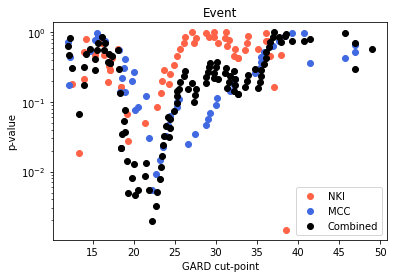

In [13]:
# overlying gard_iter plots
fig1 = plt.figure()
plt.title("Event")
plt.scatter(gard1, p_vals1, color='tomato', label='NKI')
plt.scatter(gard2, p_vals2, color='royalblue', label='MCC')
plt.scatter(gard3, p_vals3, color='black', label='Combined')
plt.xlabel('GARD cut-point')
plt.ylabel('p-value')
plt.yscale('log')
plt.legend()


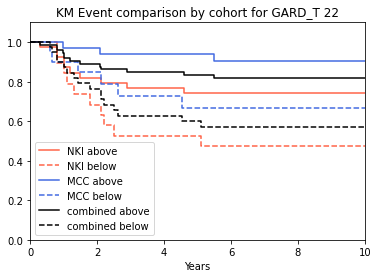

In [14]:
# overlying KM event curves for cutoff GARD
fig2 = a1.plot(color='tomato', ci_show=False, label='NKI above')
b1.plot(ax=fig2, color='tomato', linestyle='dashed', ci_show=False, label='NKI below')
a2.plot(ax=fig2, color='royalblue', ci_show=False, label='MCC above')
b2.plot(ax=fig2, color='royalblue', linestyle='dashed', ci_show=False, label='MCC below')
a3.plot(ax=fig2, color='black', ci_show=False, label='combined above')
b3.plot(ax=fig2, color='black', linestyle='dashed', ci_show=False, label='combined below')
plt.title('KM Event comparison by cohort for GARD_T ' + str(cut))
plt.xlim([0,10])
plt.ylim([0,1.1])
plt.xlabel('Years')
plt.yscale('linear')

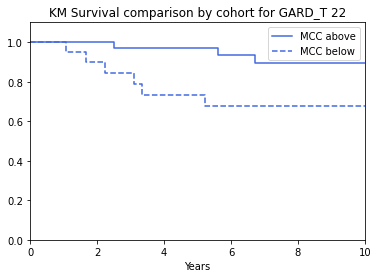

In [15]:
# KM survival curves for cutoff GARD
fig3 = a4.plot(color='royalblue', ci_show=False, label='MCC above')
b4.plot(ax=fig3, color='royalblue', linestyle='dashed', ci_show=False, label='MCC below')
plt.title('KM Survival comparison by cohort for GARD_T ' + str(cut))
plt.xlim([0,10])
plt.ylim([0,1.1])
plt.xlabel('Years')
plt.yscale('linear')

(-0.2, 1.1)

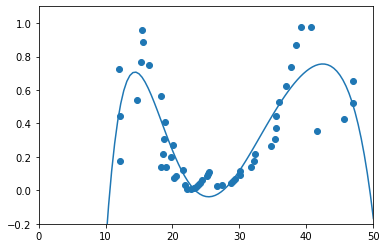

In [16]:
# finding min
coeff = np.polyfit(gard2, p_vals2, 6)
p = np.poly1d(coeff)
x = np.linspace(5, 50, num=100)
y = p(x)
fig = plt.figure()
plt.plot(x,y)
plt.scatter(gard2,p_vals2)
# plt.yscale('log')
plt.xlim([0,50])
plt.ylim([-0.2,1.1])

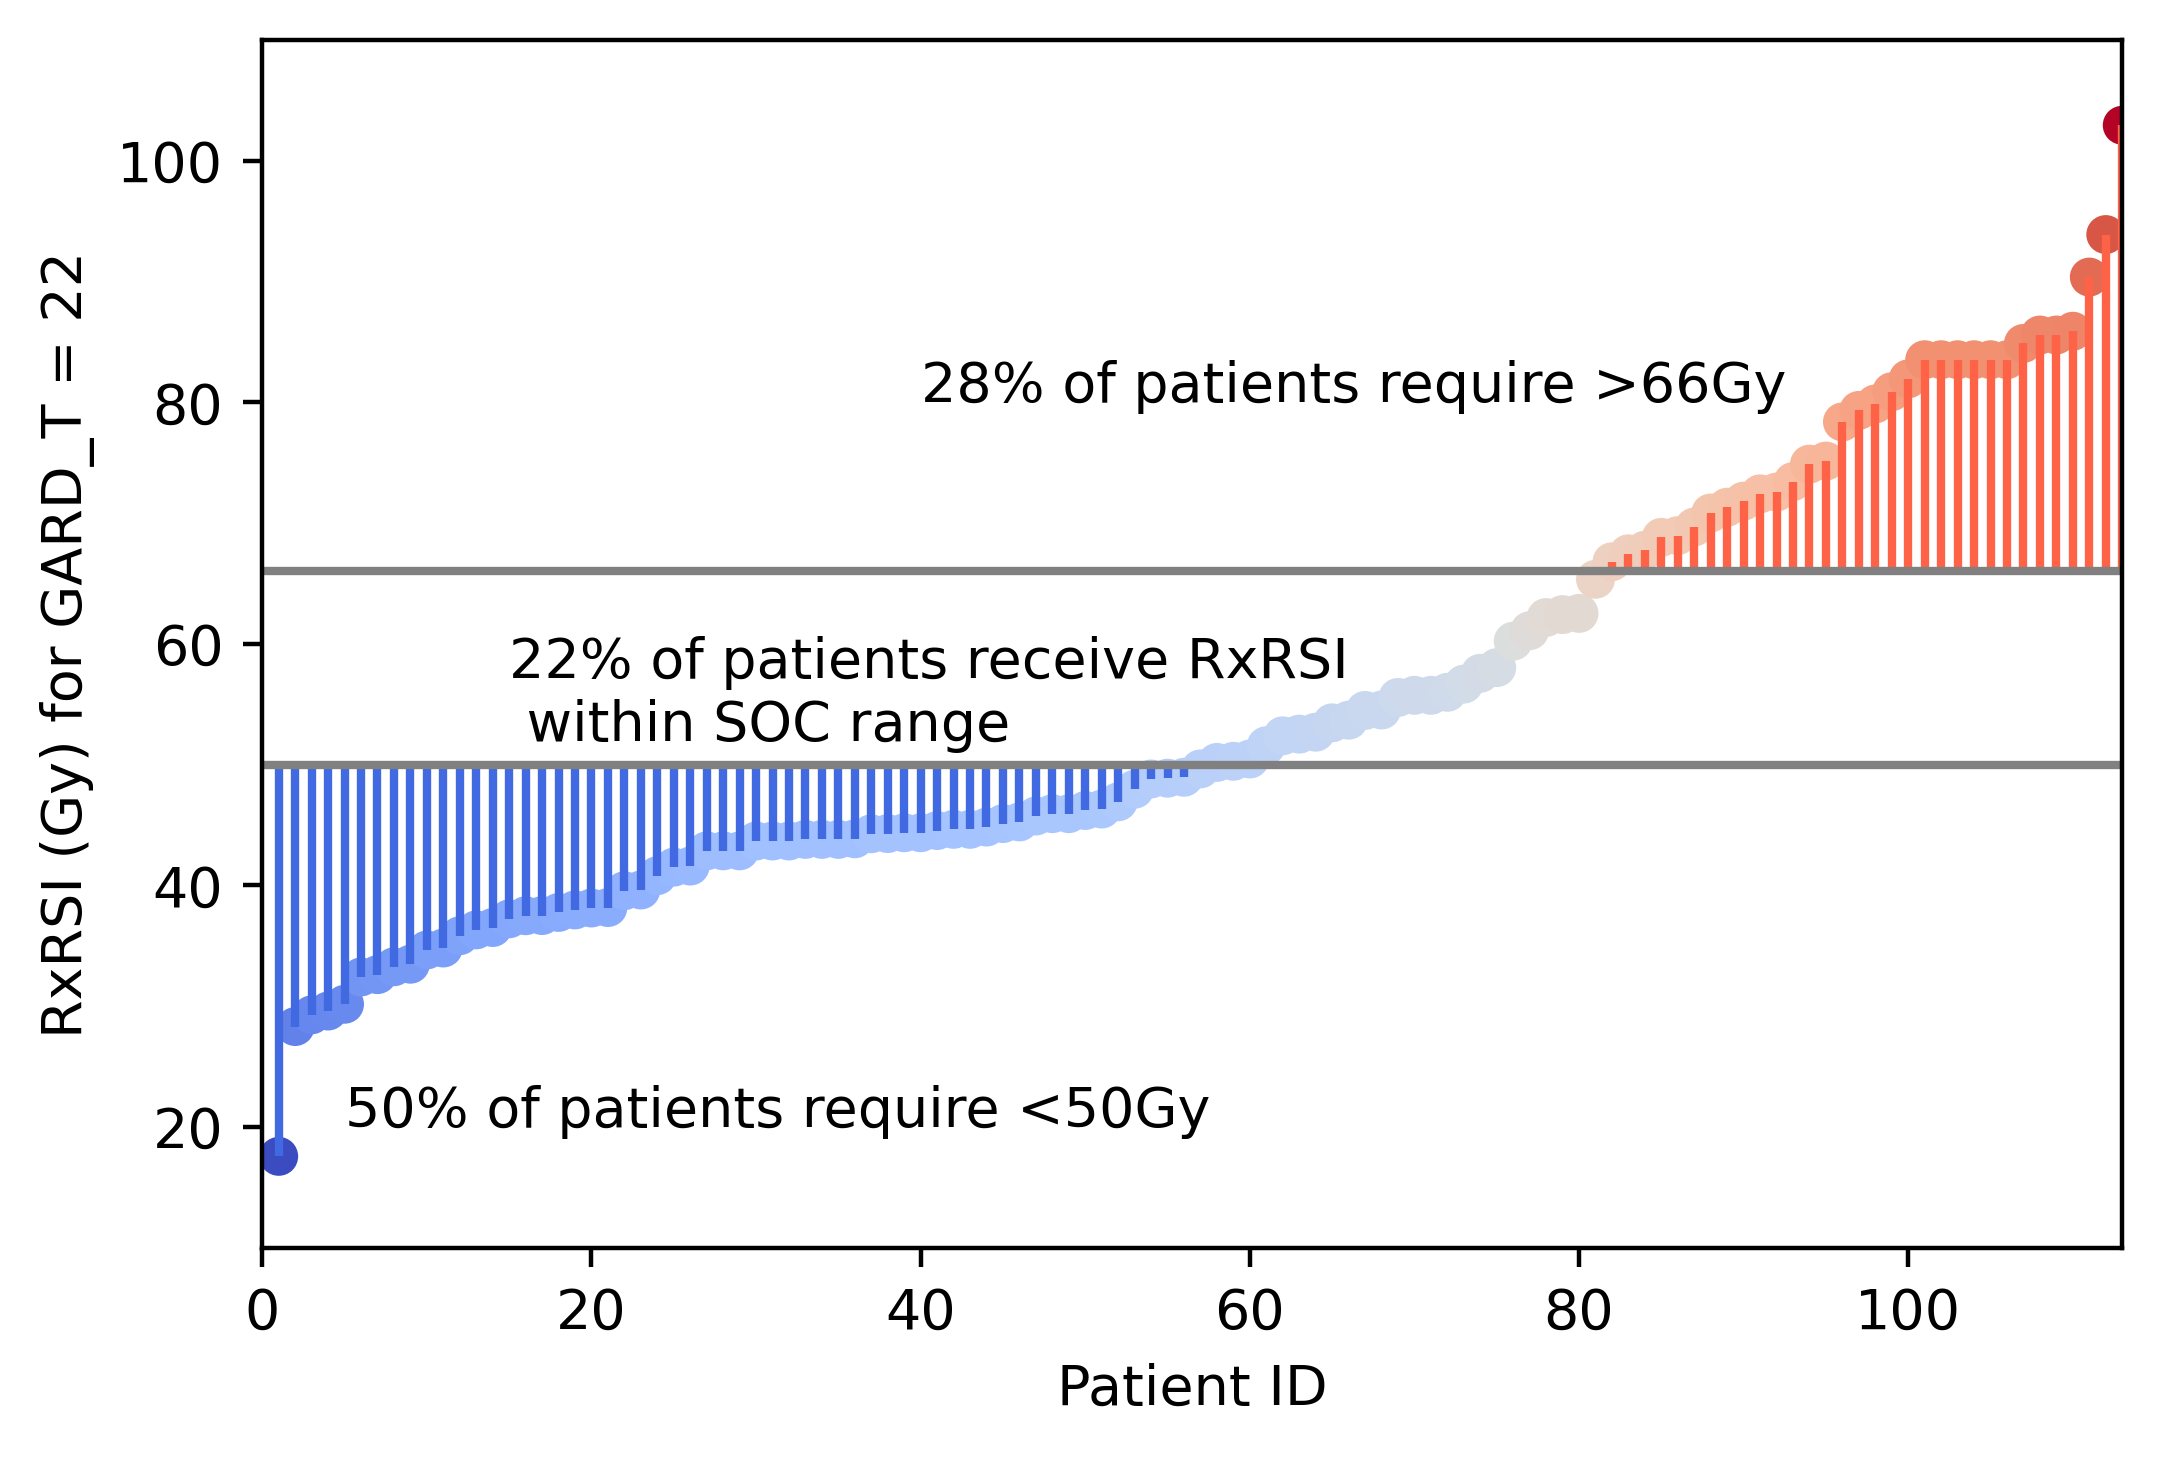

In [20]:
# making figure 1b
# sort by RxRSI
df2 = df.sort_values(by='RxRSI').reset_index().drop(columns=['index'])
# group relative to the SOC range
hlines = []
llines = []
for i in range(len(df2)):
    y = df2['RxRSI'].loc[i] 
    if y < low:
        llines.append([(i+1,y),(i+1,low)])
    if y > high:
        hlines.append([(i+1,high),(i+1,y)])
# percentages for legend
lperc = round(100*len(llines)/len(df2))
hperc = round(100*len(hlines)/len(df2))
mperc = 100 - lperc - hperc

# below here actually makes the plot
hlinecoll = matcoll.LineCollection(hlines, colors='tomato')
llinecoll = matcoll.LineCollection(llines, colors='royalblue')
fig, ax = plt.subplots(dpi=400)
ax.add_collection(hlinecoll)
ax.add_collection(llinecoll)
plt.scatter(np.linspace(1,len(df2),len(df2)),df2['RxRSI'],c=df2['RxRSI'],cmap='coolwarm')
plt.axhline(y=low,color='gray')
plt.axhline(y=high,color='gray')
plt.xlim([0,len(df2)])
plt.ylim([10,110])
plt.xlabel('Patient ID')
plt.ylabel('RxRSI (Gy) for GARD_T = '+str(gard_t))
plt.text(5, 20, str(lperc)+'% of patients require <'+str(low)+'Gy')
plt.text(15, 52, str(mperc)+'% of patients receive RxRSI \n within SOC range')
plt.text(40, 80, str(hperc)+'% of patients require >'+str(high)+'Gy')
plt.show()

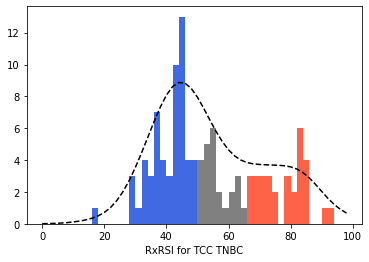

In [21]:
# fig 1c (need to run the part for 1b first though)
# CAUTION the color cutoff depends on the bin arrangement
# the PDF is also scaled manually
fig, ax = plt.subplots()
xmax = round(max(df['RxRSI']/20))*20 - 2
xint = round(max(df['RxRSI']/20))*10
x = np.linspace(0,xmax,xint)
array = df['RxRSI']
N, bins, patches = ax.hist(array,bins=x)
bw = 1.2*array.std()*np.power(array.size,-1/5)
kde = stats.gaussian_kde(array)
scale = 350 # idk if this is the right scale but it's eyeballed
curve = scale*kde(x)
for i in range(0,int(low/2)):
    patches[i].set_facecolor('royalblue')
for i in range(int(low/2),int(high/2)):    
    patches[i].set_facecolor('gray')
for i in range(int(high/2),xint-1):
    patches[i].set_facecolor('tomato') 
# plt.axvline(x=low, color='gray', linestyle='dashed')
# plt.axvline(x=high, color='gray', linestyle='dashed')
plt.xlabel("RxRSI for TCC TNBC")
plt.plot(x, curve, linestyle="dashed", color='black')

<AxesSubplot:>

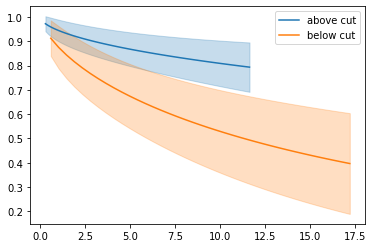

In [14]:
# weibull fits for event above and below cut
# overall event, not survival

h = df.loc[df['GARD'] > cut]
S1 = WeibullFitter()
S1.fit(h['Time'],h['Event'])
l = df.loc[df['GARD'] <= cut]
S2 = WeibullFitter()
S2.fit(l['Time'],l['Event'])
# save fit parameters
s1_lambda = S1.lambda_ # adequate dose
s1_rho = S1.rho_
s2_lambda = S2.lambda_ # inadequate
s2_rho = S2.rho_
# plot weibull fit
fig2 = S1.plot_survival_function(label='above cut')
S2.plot_survival_function(ax=fig2, label='below cut')
# a3.plot(ax=fig2, color='black', ci_show=False, label='combined above')
# b3.plot(ax=fig2, color='black', linestyle='dashed', ci_show=False, label='combined below')

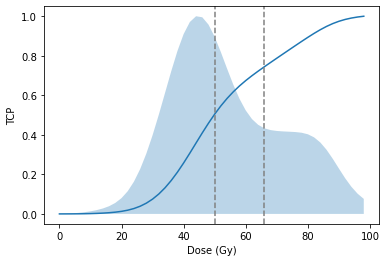

In [22]:
# plot 2a
# the different 'x' may get confusing here
pdf_scaled = kde(x)/max(kde(x))
plt.fill_between(x, y1=pdf_scaled, y2=0, alpha=0.3) #, label="PDF"
pdf = kde.evaluate(x)/sum(kde.evaluate(x))
cdf = np.cumsum(pdf)
plt.plot(x, cdf, label="TCP")
plt.axvline(x=low, color='gray', linestyle='dashed')
plt.axvline(x=high, color='gray', linestyle='dashed')
plt.xlabel("Dose (Gy)")
plt.ylabel("TCP")
# plt.legend()
plt.show()

In [29]:
# calc mean heart dose then card RR from total breast dose
def rr_card(td, side=None, CI=None):
    
    mhdL = np.poly1d(coeffL)
    mhdR = np.poly1d(coeffR)
    
    if CI==None: card_slope = 0.074
    elif CI == 'upper': card_slope = 0.145
    elif CI == 'lower': card_slope = 0.029
    
    if side==None: rr = 1 + card_slope*(mhdL(td)-mhdL(0)+mhdR(td)-mhdR(0))/2
    if side == 'L': rr = 1 + card_slope * (mhdL(td)-mhdL(0))
    if side == 'R': rr = 1 + card_slope * (mhdR(td)-mhdR(0))
            
    return rr

    
# calc mean lung dose then pulm HR from total breast dose
def hr_pulm(td, CI=None):
    
    mld = np.poly1d(coeffLung)
    MLD = mld(td)
    
    # constants from QUANTEC lung
    b0 = -3.87 
    b1 = 0.126  
    
    # for relative to dose 0
    constant = np.exp(b0)/(1+np.exp(b0))
    
    # TD50 = 30.75 [28.7–33.9] Gy
    if CI == 'upper':
        b0 = -3.33
        b1 = .153
    elif CI == 'lower': 
        b0 = -4.49
        b1 = .100
        
    hr = np.exp(b0+b1*MLD)/(1+np.exp(b0+b1*MLD)) - constant
       
    return hr

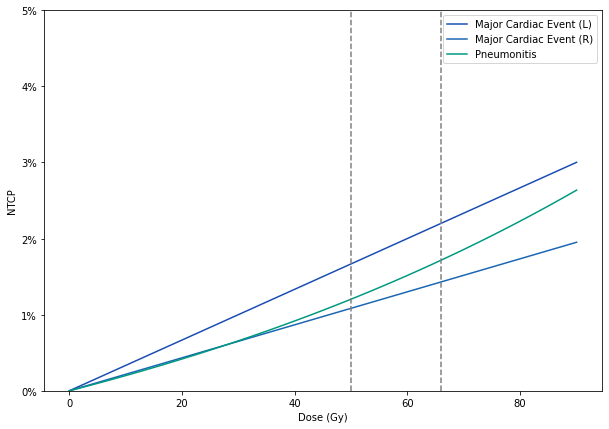

In [25]:
# fig 2b
td = np.linspace(0,90,91)
# from table 3, lifetime risk for 45yo women, total events related to atherosclerotic disease
# https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3336876/
pts_strat = np.array([7.1, 14.4, 22, 40.1, 16.4])/100
strat_mce = np.array([4.1, 12.2, 15.6, 20.2, 30.7])/100
card_base = np.sum(pts_strat*strat_mce)

hr_cL = (rr_card(td,'L') - 1) * card_base
hr_cR = (rr_card(td,'R') - 1) * card_base
hr_p = hr_pulm(td)

fig, ax = plt.subplots(figsize=(10,7))
plt.plot(td, hr_cL, color=(.1,.3,.7), label="Major Cardiac Event (L)")
plt.plot(td, hr_cR, color=(.1,.4,.7), label="Major Cardiac Event (R)")
plt.plot(td, hr_p, color=(0,.6,.5), label="Pneumonitis")
plt.axvline(x=low, color='gray', linestyle='dashed')
plt.axvline(x=high, color='gray', linestyle='dashed')
plt.xlabel("Dose (Gy)")
plt.ylabel("NTCP") # by HR
plt.ylim([0,0.05])
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:0.0%}'.format(y))) 
plt.legend()

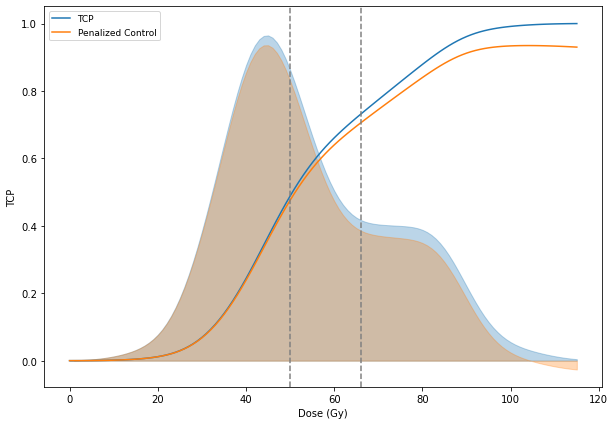

In [26]:
# fig 2c; need to run code for other parts of plot 2 first
fig = plt.figure(figsize=(10,7))
x = np.linspace(0,115,116)
scale = 38 # idk if this is the right scale but it's eyeballed
# TCP = unpenalized local control
kde = stats.gaussian_kde(df['RxRSI'])
curve1 = kde(x)
plt.fill_between(x, y1=scale*curve1, y2=0, color='tab:blue', alpha=0.3) 
pdf1 = kde.evaluate(x)/sum(kde.evaluate(x))
cdf1 = np.cumsum(pdf1)
plt.plot(x, cdf1, color='tab:blue', label="TCP")
# TCP - NTCP = penalized
hr_p = hr_pulm(x)
hr_c = card_base/2 * (rr_card(x,'L') + rr_card(x,'R') - 2)
# cdf2 = np.power(cdf1, 1+hr_p+hr_c)
cdf2 = cdf1*(1 - hr_p - hr_c)
plt.plot(x, cdf2, color='tab:orange', label="Penalized Control")
pdf2 = np.diff(cdf2) #THIS ASSUMES Y-VALUES ARE 1 APART
plt.fill_between(x[1:], y1=scale*pdf2, y2=0, color='tab:orange', alpha=0.3)

plt.axvline(x=low, color='gray', linestyle='dashed')
plt.axvline(x=high, color='gray', linestyle='dashed')
plt.xlabel("Dose (Gy)")
plt.ylabel("TCP")
plt.legend(fontsize=9)

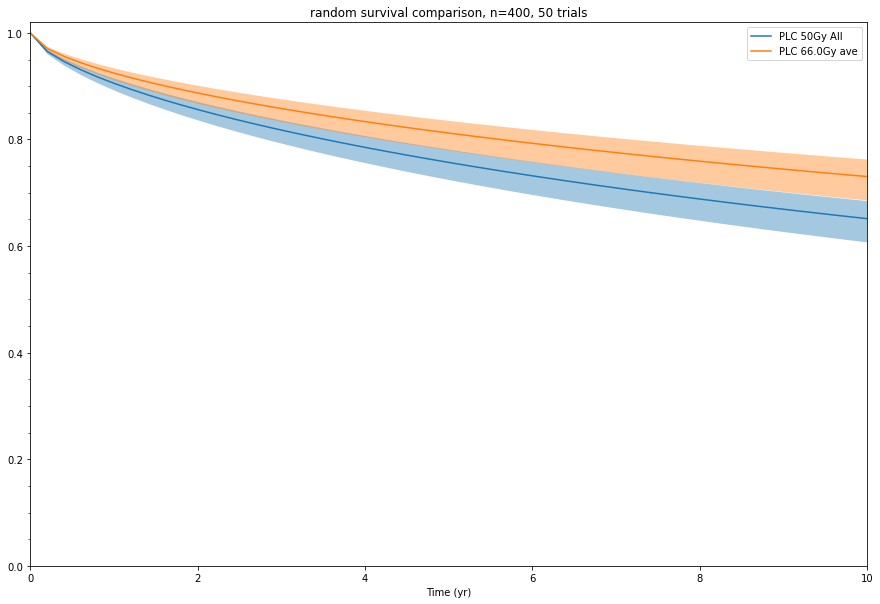

In [71]:
# PLC of averaged LC
# ignores side, invidual tox doses
# SE calculation is different too

# for 2N patients, draw from RSI distribution
def rsi_sample(N, distr):

    # for some reason this was originally giving identical samples but seems fine now
    kde = stats.gaussian_kde(distr)
    patients = kde.resample(2*N).flatten()
    patients[patients<0] = 0.001
    # rsi_sample = np.random.normal(loc=0.4267245088495575, scale=0.11221246412456044, size=2*N)
    return patients

def adj_surv(surv, td, CI=None):
    
    rr = rr_card(td, None, CI)
    hr = hr_pulm(td, CI)
    adj = np.power(surv, np.exp(hr)*rr)
        
    return adj

rsi_l = np.exp(-n*d*cut/low) # minimum RSI dose
rsi_h = np.exp(-n*d*cut/high) 

# returns UNPENALIZED survival curves for 2 treatment groups (control and boosted)
# calls s1, s2
def trial(patients, t, style):
    
    N = int(len(patients)/2)
    
    # calculate GARD, RxRSI 
    # assumes 2Gy dose
    patients['RxRSI'] = -n*d*cut/np.log(patients['RSI'])
    # initialize settings
    patients['side'] = list('LR'*N)
    patients['trt'] = 'no boost'
    patients['TD'] = low
    
    grp1 = patients[:N].copy()
    grp2 = patients[N:].copy()
    
    if style == 'random': # randomized trial

        grp2['trt'] = 'boost'
        grp2['TD'] = high
        
    # for boost grp, only RSI in middle range get boost
    if style == 'sorted': 
     
        grp2.loc[((grp2['RSI']>rsi_l) & (grp2['RSI']<rsi_h)),'TD'] = high 
        grp2.loc[(grp2['TD']==high), 'trt'] = 'boost'
        
    # judging by results this may be glitching
    # NEED TO CHECK THESE CLIP MIN/MAX
    if style == 'custom': # for boost grp, TD = RxRSI within range

        grp2['trt'] = 'boost'
        grp2['TD'] = list(grp2['RxRSI'].clip(45, 80))
 
    sat1 = len(grp1[grp1['TD']>=grp1['RxRSI']])/N
    sat2 = len(grp2[grp2['TD']>=grp2['RxRSI']])/N
    
#     print(sat1, sat2)
    
    surv1 = sat1*s1(t) + (1-sat1)*s2(t)
    surv2 = sat2*s1(t) + (1-sat2)*s2(t)
    
    dose2 = grp2['TD'].mean()
    
    return surv1, surv2, dose2

 
N = 200
rsi_distr = tcc['RSI']
tmin = 0
tmax = 10
t = np.linspace(tmin, tmax) # time axis in years
style = 'custom'

repeats = 10
results_all = np.empty([repeats, 2, len(t)]) # pd.DataFrame()
boost_doses = np.empty(repeats)

for i in range(repeats):
    
    patients = pd.DataFrame(rsi_sample(N, rsi_distr), columns=['RSI'])
    results_all[i,0], results_all[i,1], boost_doses[i] = trial(patients, t, style)
#     results_all[i,0] = np.array(surv1)
#     results_all[i,1] = np.array(surv2)
    
# geoff:

# PLC of averaged LC

# for 2N patients, draw from RSI distribution
def rsi_sample(N, distr):

    # for some reason this was originally giving identical samples but seems fine now
    kde = stats.gaussian_kde(distr)
    patients = kde.resample(2*N).flatten()
    patients[patients<0] = 0.001
    # rsi_sample = np.random.normal(loc=0.4267245088495575, scale=0.11221246412456044, size=2*N)
    return patients

rsi_l = np.exp(-n*d*cut/low) # minimum RSI dose
rsi_h = np.exp(-n*d*cut/high) 

# returns UNPENALIZED survival curves for 2 treatment groups (control and boosted)
# calls s1, s2
def trial(patients, t, style):
    
    N = int(len(patients)/2)
    
    # calculate GARD, RxRSI 
    # assumes 2Gy dose
    patients['RxRSI'] = -n*d*cut/np.log(patients['RSI'])
    # initialize settings
    patients['side'] = list('LR'*N)
    patients['trt'] = 'no boost'
    patients['TD'] = low
    
    grp1 = patients[:N].copy()
    grp2 = patients[N:].copy()
    
    if style == 'random': # randomized trial

        grp2['trt'] = 'boost'
        grp2['TD'] = high
        
    # for boost grp, only RSI in middle range get boost
    if style == 'sorted': 
     
        grp2.loc[((grp2['RSI']>rsi_l) & (grp2['RSI']<rsi_h)),'TD'] = high 
        grp2.loc[(grp2['TD']==high), 'trt'] = 'boost'
        
    # judging by results this may be glitching
    # NEED TO CHECK THESE CLIP MIN/MAX
    if style == 'custom': # for boost grp, TD = RxRSI within range

        grp2['trt'] = 'boost'
        grp2['TD'] = list(grp2['RxRSI'].clip(45, 80))
 
    sat1 = len(grp1[grp1['TD']>=grp1['RxRSI']])/N
    sat2 = len(grp2[grp2['TD']>=grp2['RxRSI']])/N
    
#     print(sat1, sat2)
    
    surv1 = sat1*s1(t) + (1-sat1)*s2(t)
    surv2 = sat2*s1(t) + (1-sat2)*s2(t)
    
    dose2 = grp2['TD'].mean()
    
    return surv1, surv2, dose2

 
N = 200
rsi_distr = tcc['RSI']
tmin = 0
tmax = 10
t = np.linspace(tmin, tmax) # time axis in years
style = 'random'

repeats = 50
results_all = np.empty([repeats, 2, len(t)]) # pd.DataFrame()
boost_doses = np.empty(repeats)

for i in range(repeats):
    
    patients = pd.DataFrame(rsi_sample(N, rsi_distr), columns=['RSI'])
    results_all[i,0], results_all[i,1], boost_doses[i] = trial(patients, t, style)
#     results_all[i,0] = np.array(surv1)
#     results_all[i,1] = np.array(surv2)
    
# geoff:
# average and std deviation for lc results all trials
lc1_ave = np.average(results_all[:,0], axis=0)
lc2_ave = np.average(results_all[:,1], axis=0)
lc1_SE = np.std(results_all[:,0],axis=0) # difference between trials
lc2_SE = np.std(results_all[:,1],axis=0)
boosted = np.average(boost_doses)
# penalize and plot
fig,ax = plt.subplots(figsize = (15,10),sharex=False)
plc1 = adj_surv(lc1_ave,low,CI=None)
upper1 = adj_surv(lc1_ave + 2*lc1_SE,low,'lower')
lower1 = adj_surv(lc1_ave - 2*lc1_SE,low,'upper')
plc2 = adj_surv(lc2_ave,boosted,CI=None)
upper2 = adj_surv(lc2_ave + 2*lc2_SE,boosted,'lower')
lower2 = adj_surv(lc2_ave - 2*lc2_SE,boosted,'upper')

ax.plot(t, plc1, label='PLC '+str(low)+'Gy All')
ax.fill_between(t, upper1, lower1, alpha=.4) # color=cp[0]
ax.plot(t, plc2, label='PLC '+str(boosted)+'Gy ave')
ax.fill_between(t, upper2, lower2, alpha=.4) # color=cp[0]
ax.set_yticks(np.arange(0,1.2,.2),minor=False)
ax.set_xlabel('Time (yr)')
if i == 0: ax.set_ylabel('Probability of Event')
ax.set_yticks(np.arange(0,1,.05),minor=True)
ax.set_xbound(0,10)
ax.set_ylim(0,1.02)
plt.title(style+' survival comparison, n='+str(2*N)+', '+str(repeats)+' trials')
ax.legend()

In [28]:
# accounts for OAR survival cost from original tumor control

# def adj_surv(surv, td, side):
    
#     rr = rr_card(td, side)
#     hr = hr_pulm(td)
#     adj = np.power(surv, np.exp(hr)*rr)
    
#     return adj


(0.0, 1.0)

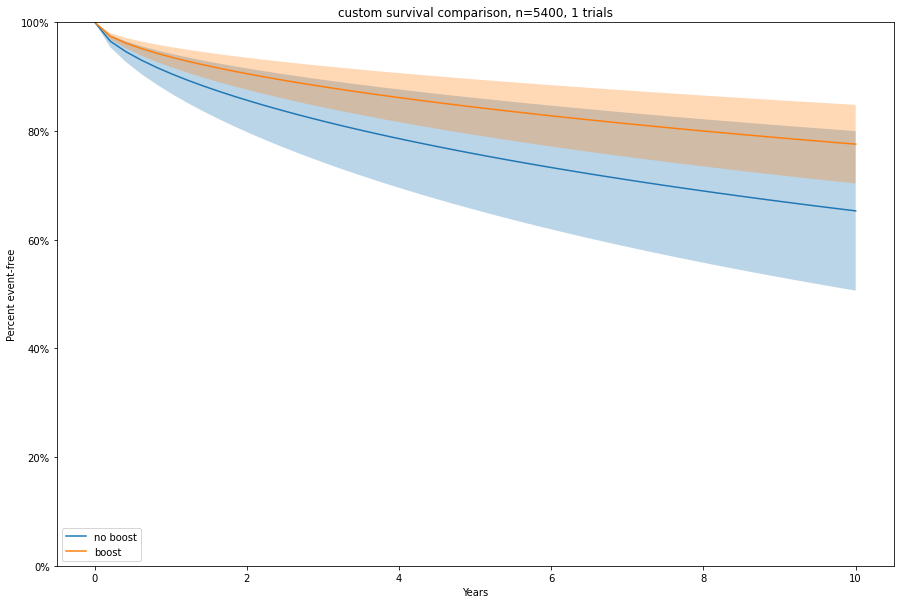

In [76]:
# individual ntcp

# for 2N patients, draw from RSI distribution
def rsi_sample(N, distr):

    # for some reason this was originally giving identical samples but seems fine now
    kde = stats.gaussian_kde(distr)
    patients = kde.resample(2*N).flatten()
    patients[patients<0] = 0.001
    # rsi_sample = np.random.normal(loc=0.4267245088495575, scale=0.11221246412456044, size=2*N)
    return patients

def adj_surv(surv, td, side=None, CI=None):
    
    rr = rr_card(td, side, CI)
    hr = hr_pulm(td, CI)
    adj = np.power(surv, np.exp(hr)*rr)
        
    return adj

rsi_l = np.exp(-n*d*cut/low) # minimum RSI dose
rsi_h = np.exp(-n*d*cut/high) 

# returns UNPENALIZED survival curves for 2 treatment groups (control and boosted)
# calls s1, s2
def trial(temp, t, style):
    
    N = int(len(temp)/2)
    
    # calculate GARD, RxRSI 
    # assumes 2Gy dose
    temp['RxRSI'] = -n*d*cut/np.log(temp['RSI'])
    # initialize settings
    temp['side'] = list('LR'*N)
    temp['trt'] = 'no boost'
    temp['TD'] = low
    
    grp1 = temp[:N].copy()
    grp2 = temp[N:].copy()
    
    if style == 'random': # randomized trial

        grp2['trt'] = 'boost'
        grp2['TD'] = high
        
    # for boost grp, only RSI in middle range get boost
    if style == 'sorted': 
     
        grp2.loc[((grp2['RSI']>rsi_l) & (grp2['RSI']<rsi_h)),'TD'] = high 
        grp2.loc[(grp2['TD']==high), 'trt'] = 'boost'
        
    # judging by results this may be glitching
    # NEED TO CHECK THESE CLIP MIN/MAX
    if style == 'custom': # for boost grp, TD = RxRSI within range

        grp2['trt'] = 'boost'
        grp2['TD'] = list(grp2['RxRSI'].clip(45, 80))
     
    noboost_count = grp2[grp2['TD']==low].count()
    boost_count = grp2[grp2['TD']>low].count()
      
    # model penalized survival 
    surv1 = []    
    for index, patient in grp1.iterrows():
        
        # select based on whether or not RxRSI is met
        if patient['TD']>=patient['RxRSI']: lc = s1(t)
        else: lc = s2(t)
            
        # adjust for tox (penalized local control)
        plc = adj_surv(lc, patient['TD'], patient['side'])
        surv1.append(plc)
    
    surv2 = []
    for index, patient in grp2.iterrows():
        
        # select based on whether or not RxRSI is met
        if patient['TD']>=patient['RxRSI']: lc = s1(t)
        else: lc = s2(t)
            
        # adjust for tox (penalized local control)
        plc = adj_surv(lc, patient['TD'], patient['side'])
        surv2.append(plc)
    
    return surv1, surv2

 
N = 2700
rsi_distr = tcc['RSI']
tmin = 0
tmax = 10
t = np.linspace(tmin, tmax) # time axis in years
style = 'custom'
repeats = 1

curve1 = []
curve2 = []
var1 = []
var2 = []
for i in range(repeats):
    
    patients = pd.DataFrame(rsi_sample(N, rsi_distr), columns=['RSI'])
    surv1, surv2 = trial(patients, t, style)
    curve1.append(np.mean(surv1, axis=0))
    curve2.append(np.mean(surv2, axis=0))
    var1.append(np.var(surv1, axis=0))
    var2.append(np.var(surv2, axis=0))
    
plc1 = np.mean(curve1, axis=0)
plc2 = np.mean(curve2, axis=0)
se1 = 0
se2 = 0
for i in range(repeats):
    se1 += (N-1)*var1[i] + N*np.square(curve1[i]-plc1)
    se2 += (N-1)*var2[i] + N*np.square(curve2[i]-plc2)
se1 = np.sqrt(se1/(N*repeats-1))
se2 = np.sqrt(se2/(N*repeats-1))

fig, ax = plt.subplots(figsize=(15,10))
# should this be 2stdev?
plt.fill_between(t, plc1-se1, plc1+se1, alpha=.3) 
plt.fill_between(t, plc2-se2, plc2+se2, alpha=.3) 
plt.plot(t, plc1, label='no boost')
plt.plot(t, plc2, label='boost')
plt.legend(loc='lower left')
plt.xlabel('Years')
plt.ylabel('Percent event-free')
plt.title(style+' survival comparison, n='+str(2*N)+', '+str(repeats)+' trials')
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y))) 
plt.ylim(0,1)

50